In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
import gzip

from sklearn.metrics import accuracy_score


训练数据

In [2]:

with gzip.open('train-images-idx3-ubyte.gz', 'rb') as f:
    train_images = np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28*28)
with gzip.open('train-labels-idx1-ubyte.gz', 'rb') as f:
    train_labels = np.frombuffer(f.read(), np.uint8, offset=8)

测试数据

In [3]:
with gzip.open('t10k-images-idx3-ubyte.gz', 'rb') as f:
    test_images = np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28*28)
with gzip.open('t10k-labels-idx1-ubyte.gz', 'rb') as f:
    test_labels = np.frombuffer(f.read(), np.uint8, offset=8)

In [4]:
train_images = train_images.astype(np.float32) / 255.0#数据预处理的归一化
test_images=test_images.astype(np.float32) / 255.0

In [5]:
scaler=StandardScaler()#标准化数据
train_images_scaled = scaler.fit_transform(train_images)
test_images_scaled=scaler.transform(test_images)

In [6]:
print(f"训练集大小: {len(train_images_scaled)}")
print(f"测试集大小: {len(test_images_scaled)}")


训练集大小: 60000
测试集大小: 10000


In [7]:

X_train = train_images_scaled
y_train = train_labels
X_test = test_images_scaled
y_test = test_labels

print(f"训练集: {X_train.shape}")
print(f"测试集: {X_test.shape}")


训练集: (60000, 784)
测试集: (10000, 784)


In [9]:

print(X_train.shape)

(60000, 784)


In [18]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_train)
var_ratio=pca.explained_variance_ratio_
print(var_ratio)


[0.22083548 0.14414632 0.05461176]


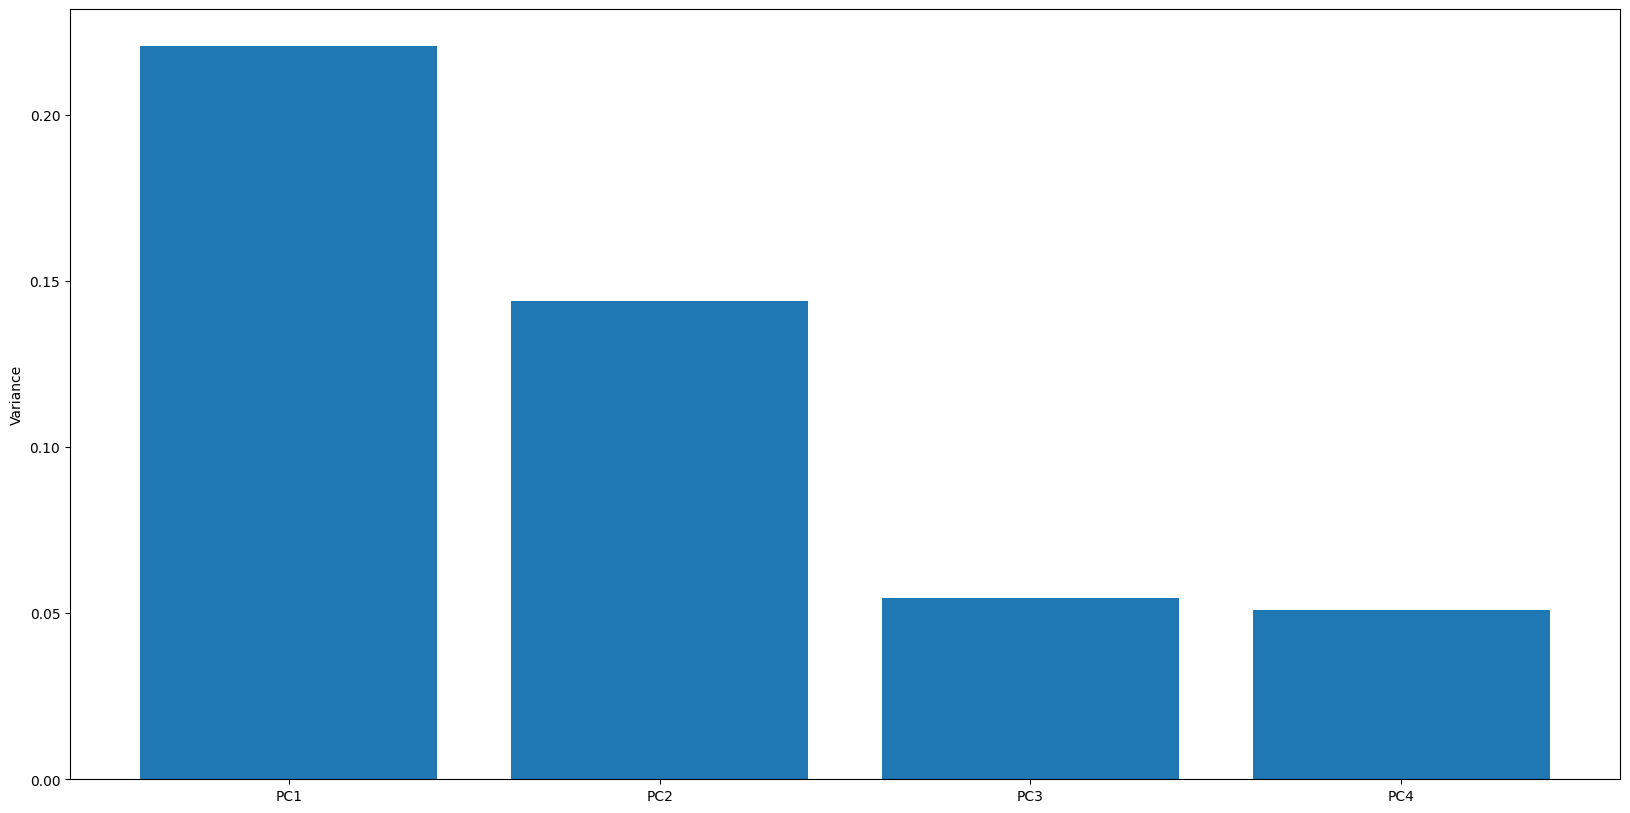

In [16]:
fig2=plt.figure(figsize=[20,10])
plt.bar([1,2,3,4],var_ratio)
plt.xticks([1,2,3,4],['PC1','PC2','PC3','PC4'])
plt.ylabel('Variance')
plt.show()

In [17]:
from sklearn.svm import SVC
SVM=SVC(kernel='rbf', C=10, gamma='scale',cache_size=5000, random_state=42)
SVM.fit(X_train,y_train)
y_predict=SVM.predict(X_test)
print(y_predict)
acc=accuracy_score(y_test,y_predict)
print(acc)

[9 2 1 ... 8 1 5]
0.8986


In [19]:
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
RF.fit(X_train, y_train)

y_predict=RF.predict(X_test)
print(y_predict)
acc=accuracy_score(y_test,y_predict)
print(acc)


[9 2 1 ... 8 1 5]
0.8759


In [20]:

from sklearn.neighbors import KNeighborsClassifier
KNN=KNeighborsClassifier(n_neighbors=5)
KNN.fit(X_train,y_train)
y_predict=KNN.predict(X_test)
print(y_predict)
acc=accuracy_score(y_test,y_predict)
print(acc)

[9 2 1 ... 8 1 5]
0.8533


In [21]:
from sklearn.linear_model import LogisticRegression
L1=LogisticRegression()
L1.fit(X_train,y_train)
y_predict=L1.predict(X_test)
print(y_predict)
acc=accuracy_score(y_test,y_predict)
print(acc)

[9 2 1 ... 6 1 5]
0.8433


C:\Users\25776\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
